# Month-year lambda


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from scipy.linalg import expm, solve_continuous_lyapunov
from scipy.stats import pearsonr, spearmanr
from IPython.display import display

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

MONTH_NAMES = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

def load_named_params(path):
    df = pd.read_csv(path)
    name_col = "name" if "name" in df.columns else df.columns[0]
    value_col = "value" if "value" in df.columns else df.columns[1]
    return dict(zip(df[name_col].astype(str), df[value_col].astype(float)))

def build_carma_from_params(path):
    params = load_named_params(path)
    a_names = sorted([k for k in params if k.startswith("a")], key=lambda s: int(s[1:]))
    b_names = sorted([k for k in params if k.startswith("b")], key=lambda s: int(s[1:]))
    p = len(a_names)
    A = np.zeros((p, p), dtype=float)
    if p > 1:
        A[:-1, 1:] = np.eye(p - 1)
    A[-1, :] = -np.array([params[f"a{i}"] for i in range(p, 0, -1)], dtype=float)
    b = np.zeros(p, dtype=float)
    for name in b_names:
        j = int(name[1:])
        if j < p:
            b[j] = params[name]
    e = np.zeros(p, dtype=float)
    e[-1] = 1.0
    return A, b, e, float(params["sig"]), params

A_T, b_T, e_T, sigma_T, params_T = build_carma_from_params("../data/kalman/temp_carma_params.csv")
A_X, b_X, e_X, sigma_X_marginal, params_X = build_carma_from_params("../data/kalman/price_carma_params.csv")

p_T, p_X = A_T.shape[0], A_X.shape[0]
h = 1.0

carma_parameter_table = pd.DataFrame({
    "p": [p_T, p_X],
    "sigma": [sigma_T, sigma_X_marginal],
    "b": [np.round(b_T, 6), np.round(b_X, 6)],
}, index=["temperature", "price"])
display(carma_parameter_table)


,p,sigma,b
temperature,2,0.769633,"[1.0, 0.584421]"
price,3,0.023063,"[1.0, -1.691075, 0.085606]"


## Helpers


In [2]:
def van_loan(A, G, dt):
    """Discrete F and Q for dZ = A Z dt + G dW using Van Loan discretization."""
    n = A.shape[0]
    M = np.block([[A, G @ G.T], [np.zeros((n, n)), -A.T]]) * float(dt)
    E = expm(M)
    F = E[:n, :n]
    Q = E[:n, n:] @ F.T
    return F, 0.5 * (Q + Q.T)

def stationary_covariance(A, G):
    """Continuous-time stationary covariance, used for Kalman initialisation."""
    P = solve_continuous_lyapunov(A, -(G @ G.T))
    return 0.5 * (P + P.T)

def cross_covariance_kernel(A_T, A_X, e_T, e_X, sigma_T, dt):
    """K_TX = sigma_T^2 int_0^dt exp(A_T s)e_T e_X' exp(A_X' s) ds."""
    p_T, p_X = len(e_T), len(e_X)
    A = np.zeros((p_T + p_X, p_T + p_X))
    A[:p_T, :p_T] = A_T
    A[p_T:, p_T:] = A_X
    G = np.zeros((p_T + p_X, 1))
    G[:p_T, 0] = sigma_T * e_T
    G[p_T:, 0] = sigma_T * e_X
    _, Q = van_loan(A, G, dt)
    return Q[:p_T, p_T:]

def kf_scalar(y, A, G, H, dt, x0=None, P0=None, obs_noise=1e-8):
    """Scalar-output Kalman filter for marginal CARMA state recovery."""
    n, m = len(y), A.shape[0]
    h_vec = np.asarray(H, dtype=float).reshape(-1)
    x = np.zeros(m) if x0 is None else np.asarray(x0, dtype=float).copy()
    P = stationary_covariance(A, G) + np.eye(m) * 1e-6 if P0 is None else P0.copy()
    F, Q = van_loan(A, G, dt)
    x_filt = np.zeros((n, m))
    innov = np.zeros(n)
    S_arr = np.zeros(n)
    loglik = 0.0

    for k in range(n):
        if k > 0:
            x = F @ x
            P = F @ P @ F.T + Q
        mu = float(h_vec @ x)
        S = float(h_vec @ P @ h_vec) + obs_noise
        v = y[k] - mu
        K = (P @ h_vec) / S
        x = x + K * v
        P = (np.eye(m) - np.outer(K, h_vec)) @ P
        P = 0.5 * (P + P.T)

        x_filt[k] = x
        innov[k] = v
        S_arr[k] = S
        loglik += -0.5 * (np.log(2 * np.pi * S) + v**2 / S)

    return dict(F=F, Q=Q, x_filt=x_filt, innov=innov, S=S_arr, loglik=float(loglik))

def centered_covariance(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    return float(np.mean((x - x.mean()) * (y - y.mean())))



## Data


In [3]:
def read_residual_series(path, value_col):
    df = pd.read_csv(path, parse_dates=["datetime"])
    df["datetime"] = pd.to_datetime(df["datetime"], utc=True)
    df = df[["datetime", value_col]].dropna().sort_values("datetime")
    df = df.set_index("datetime")
    df[value_col] = df[value_col].astype(float)
    return df

temp_df = read_residual_series("../data/deseasonalised/temp_resid.csv", "temp_deseasoned")
price_df = read_residual_series("../data/deseasonalised/price_resid.csv", "price_deseasoned")

temp_mean = float(temp_df["temp_deseasoned"].mean())
price_mean = float(price_df["price_deseasoned"].mean())
temp_df["T"] = temp_df["temp_deseasoned"] - temp_mean
price_df["X"] = price_df["price_deseasoned"] - price_mean

time_T = temp_df.index
time_X = price_df.index
y_T = temp_df["T"].to_numpy(float)
y_X = price_df["X"].to_numpy(float)

residual_data_table = pd.DataFrame({
    "n": [len(y_T), len(y_X)],
    "start": [time_T.min(), time_X.min()],
    "end": [time_T.max(), time_X.max()],
    "mean_removed": [temp_mean, price_mean],
}, index=["temperature", "price"])
display(residual_data_table)


,n,start,end,mean_removed
temperature,52608,2020-01-01 00:00:00+00:00,2025-12-31 23:00:00+00:00,6.513169e-10
price,26281,2023-01-01 00:00:00+00:00,2025-12-31 00:00:00+00:00,2.072228e-05


## State residuals


In [4]:
G_T = (sigma_T * e_T).reshape(-1, 1)
G_X_marginal = (sigma_X_marginal * e_X).reshape(-1, 1)
H_T = b_T.reshape(1, -1)
H_X = b_X.reshape(1, -1)

res_kf_T = kf_scalar(y_T, A_T, G_T, H_T, h)
res_kf_X = kf_scalar(y_X, A_X, G_X_marginal, H_X, h)

xT = res_kf_T["x_filt"]
xX = res_kf_X["x_filt"]
FT, FX = res_kf_T["F"], res_kf_X["F"]

R_T = xT[1:] - (FT @ xT[:-1].T).T
R_X = xX[1:] - (FX @ xX[:-1].T).T

idx_T = pd.DatetimeIndex(time_T[1:])
idx_X = pd.DatetimeIndex(time_X[1:])
common_resid_idx = idx_T.intersection(idx_X).sort_values()
loc_T = idx_T.get_indexer(common_resid_idx)
loc_X = idx_X.get_indexer(common_resid_idx)
valid = (loc_T >= 0) & (loc_X >= 0)

common_resid_idx = common_resid_idx[valid]
R_T_c = R_T[loc_T[valid]]
R_X_c = R_X[loc_X[valid]]

R_T_obs = R_T_c @ b_T
R_X_obs = R_X_c @ b_X
years = common_resid_idx.year.to_numpy()
months = common_resid_idx.month.to_numpy()
periods = common_resid_idx.to_period("M").astype(str).to_numpy()

K_TX = cross_covariance_kernel(A_T, A_X, e_T, e_X, sigma_T, h)
denom = float(b_T @ K_TX @ b_X)

state_residual_alignment = pd.DataFrame({
    "common_residual_n": [len(common_resid_idx)],
    "period_start": [periods[0]],
    "period_end": [periods[-1]],
    "n_periods": [len(np.unique(periods))],
    "denom": [denom],
    "temp_marginal_loglik": [res_kf_T["loglik"]],
    "price_marginal_loglik": [res_kf_X["loglik"]],
}, index=["state_residuals"])
display(state_residual_alignment.round(8))


,common_residual_n,period_start,period_end,n_periods,denom,temp_marginal_loglik,price_marginal_loglik
state_residuals,26280,2023-01,2025-12,36,-0.118809,-48516.22037,78288.683595


## Constant lambda


In [5]:
constant_lambda_source = pd.read_csv("../data/levy/coupling_estimate.csv")

lambda_global = float(constant_lambda_source.loc[0, "lambda_hat"])
lambda_global_se = float(constant_lambda_source.loc[0, "se"])
lambda_global_ci = np.array([
    float(constant_lambda_source.loc[0, "ci_lo"]),
    float(constant_lambda_source.loc[0, "ci_hi"]),
])
lambda_global_t = float(constant_lambda_source.loc[0, "t_stat"])

rng = np.random.default_rng(42)

global_lambda_table = pd.DataFrame({
    "lambda_global": [lambda_global],
    "se": [lambda_global_se],
    "ci_95_lo": [lambda_global_ci[0]],
    "ci_95_hi": [lambda_global_ci[1]],
    "t_stat": [lambda_global_t],
    "model_cov_global": [lambda_global * denom],
}, index=["constant"])
display(global_lambda_table.round(8))


,lambda_global,se,ci_95_lo,ci_95_hi,t_stat,model_cov_global
constant,0.001749,0.000386,0.000948,0.002427,4.531292,-0.000208


## Month-year lambda


In [6]:
period_rows = []
n_boot_period = 1000
unique_periods = np.unique(periods)

for period in unique_periods:
    mask = periods == period
    rt = R_T_obs[mask]
    rx = R_X_obs[mask]
    n_p = len(rt)
    cov_p = centered_covariance(rt, rx)
    lambda_p = cov_p / denom

    boot = np.empty(n_boot_period)
    for j in range(n_boot_period):
        idx = rng.integers(0, n_p, size=n_p)
        boot[j] = centered_covariance(rt[idx], rx[idx]) / denom

    se = float(boot.std(ddof=1))
    ci_lo, ci_hi = np.percentile(boot, [2.5, 97.5])
    ts = pd.Period(period, freq="M").to_timestamp()
    period_rows.append({
        "period": period,
        "date": ts,
        "year": ts.year,
        "month": ts.month,
        "month_name": MONTH_NAMES[ts.month - 1],
        "n": n_p,
        "empirical_cov": cov_p,
        "lambda_period": lambda_p,
        "se": se,
        "ci_lo": ci_lo,
        "ci_hi": ci_hi,
        "includes_zero": bool(ci_lo <= 0 <= ci_hi),
        "sign": "positive" if lambda_p > 0 else "negative" if lambda_p < 0 else "zero",
    })

period_lambda = pd.DataFrame(period_rows)
period_lambda["model_cov_constant"] = lambda_global * denom
period_lambda["model_cov_period"] = period_lambda["lambda_period"] * denom
period_lambda["error_constant"] = period_lambda["empirical_cov"] - period_lambda["model_cov_constant"]
period_lambda["error_period"] = period_lambda["empirical_cov"] - period_lambda["model_cov_period"]

rmse_cov_constant = float(np.sqrt(np.mean(period_lambda["error_constant"] ** 2)))
rmse_cov_period = float(np.sqrt(np.mean(period_lambda["error_period"] ** 2)))
rmse_reduction_pct = float(100 * (1 - rmse_cov_period / rmse_cov_constant))

signs = set(period_lambda["sign"])
has_sign_changes = ("positive" in signs) and ("negative" in signs)
n_zero_ci = int(period_lambda["includes_zero"].sum())

display(period_lambda[[
    "period", "n", "empirical_cov", "lambda_period", "se", "ci_lo", "ci_hi", "includes_zero", "sign"
]].round(8))

period_fit_metrics = pd.DataFrame({
    "rmse_cov_constant": [rmse_cov_constant],
    "rmse_cov_period": [rmse_cov_period],
    "rmse_reduction_pct": [rmse_reduction_pct],
    "has_sign_changes": [has_sign_changes],
    "n_period_CI_including_zero": [n_zero_ci],
}, index=["in_sample"])
display(period_fit_metrics.round(8))


,period,n,empirical_cov,lambda_period,se,ci_lo,ci_hi,includes_zero,sign
0,2023-01,743,-1.162800e-04,0.000979,0.000999,-0.001055,0.002845,True,positive
1,2023-02,672,-5.261400e-04,0.004428,0.001662,0.001152,0.007553,False,positive
2,2023-03,744,-1.797300e-04,0.001513,0.001945,-0.002004,0.005534,True,positive
3,2023-04,720,2.468000e-05,-0.000208,0.001683,-0.003466,0.003210,True,negative
4,2023-05,744,8.551000e-05,-0.000720,0.001900,-0.004883,0.002641,True,negative
5,2023-06,720,-4.882300e-04,0.004109,0.001429,0.001420,0.006942,False,positive
6,2023-07,744,-2.728100e-04,0.002296,0.005007,-0.007066,0.012258,True,positive
7,2023-08,744,6.022000e-05,-0.000507,0.002036,-0.004807,0.003551,True,negative
8,2023-09,720,-4.639000e-04,0.003905,0.006174,-0.009673,0.014975,True,positive
9,2023-10,744,-2.772300e-04,0.002333,0.002049,-0.001592,0.006630,True,positive


,rmse_cov_constant,rmse_cov_period,rmse_reduction_pct,has_sign_changes,n_period_CI_including_zero
in_sample,0.000427,0.0,100.0,True,25


## Rolling prediction


In [7]:
pred_rows = []
period_lambda_sorted = period_lambda.sort_values("date").reset_index(drop=True)

for i in range(1, len(period_lambda_sorted)):
    current = period_lambda_sorted.iloc[i]
    history = period_lambda_sorted.iloc[:i]

    lambda_constant_hist = history["empirical_cov"].mean() / denom
    lambda_expanding_hist = history["lambda_period"].mean()

    same_month_history = history[history["month"] == current["month"]]
    if len(same_month_history) > 0:
        lambda_same_month_hist = same_month_history["lambda_period"].mean()
    else:
        lambda_same_month_hist = np.nan

    empirical_cov_test = current["empirical_cov"]
    pred_const = lambda_constant_hist * denom
    pred_expanding = lambda_expanding_hist * denom
    pred_same_month = lambda_same_month_hist * denom if not np.isnan(lambda_same_month_hist) else np.nan

    pred_rows.append({
        "period": current["period"],
        "year": int(current["year"]),
        "month": int(current["month"]),
        "month_name": current["month_name"],
        "empirical_cov": empirical_cov_test,
        "pred_cov_constant_expanding": pred_const,
        "pred_cov_lambda_expanding": pred_expanding,
        "pred_cov_same_month_history": pred_same_month,
        "error_constant_expanding": empirical_cov_test - pred_const,
        "error_lambda_expanding": empirical_cov_test - pred_expanding,
        "error_same_month_history": empirical_cov_test - pred_same_month if not np.isnan(pred_same_month) else np.nan,
    })

rolling_prediction = pd.DataFrame(pred_rows)

rmse_constant_expanding = float(np.sqrt(np.mean(rolling_prediction["error_constant_expanding"] ** 2)))
rmse_lambda_expanding = float(np.sqrt(np.mean(rolling_prediction["error_lambda_expanding"] ** 2)))
same_month_valid = rolling_prediction["error_same_month_history"].notna()
rmse_same_month_history = float(np.sqrt(np.mean(rolling_prediction.loc[same_month_valid, "error_same_month_history"] ** 2)))

mae_constant_expanding = float(np.mean(np.abs(rolling_prediction["error_constant_expanding"])))
mae_lambda_expanding = float(np.mean(np.abs(rolling_prediction["error_lambda_expanding"])))
mae_same_month_history = float(np.mean(np.abs(rolling_prediction.loc[same_month_valid, "error_same_month_history"])))

rmse_reduction_expanding_pct = float(100 * (1 - rmse_lambda_expanding / rmse_constant_expanding))
rmse_reduction_same_month_pct = float(100 * (1 - rmse_same_month_history / rmse_constant_expanding))

rolling_metrics = pd.DataFrame({
    "rmse_constant_expanding": [rmse_constant_expanding],
    "rmse_lambda_expanding": [rmse_lambda_expanding],
    "rmse_same_month_history": [rmse_same_month_history],
    "rmse_reduction_expanding_pct": [rmse_reduction_expanding_pct],
    "rmse_reduction_same_month_pct": [rmse_reduction_same_month_pct],
    "mae_constant_expanding": [mae_constant_expanding],
    "mae_lambda_expanding": [mae_lambda_expanding],
    "mae_same_month_history": [mae_same_month_history],
}, index=["rolling"])
display(rolling_metrics.round(8))


,rmse_constant_expanding,rmse_lambda_expanding,rmse_same_month_history,rmse_reduction_expanding_pct,rmse_reduction_same_month_pct,mae_constant_expanding,mae_lambda_expanding,mae_same_month_history
rolling,0.000447,0.000447,0.000572,0.0,-28.109655,0.00031,0.00031,0.00041


## Lambda path


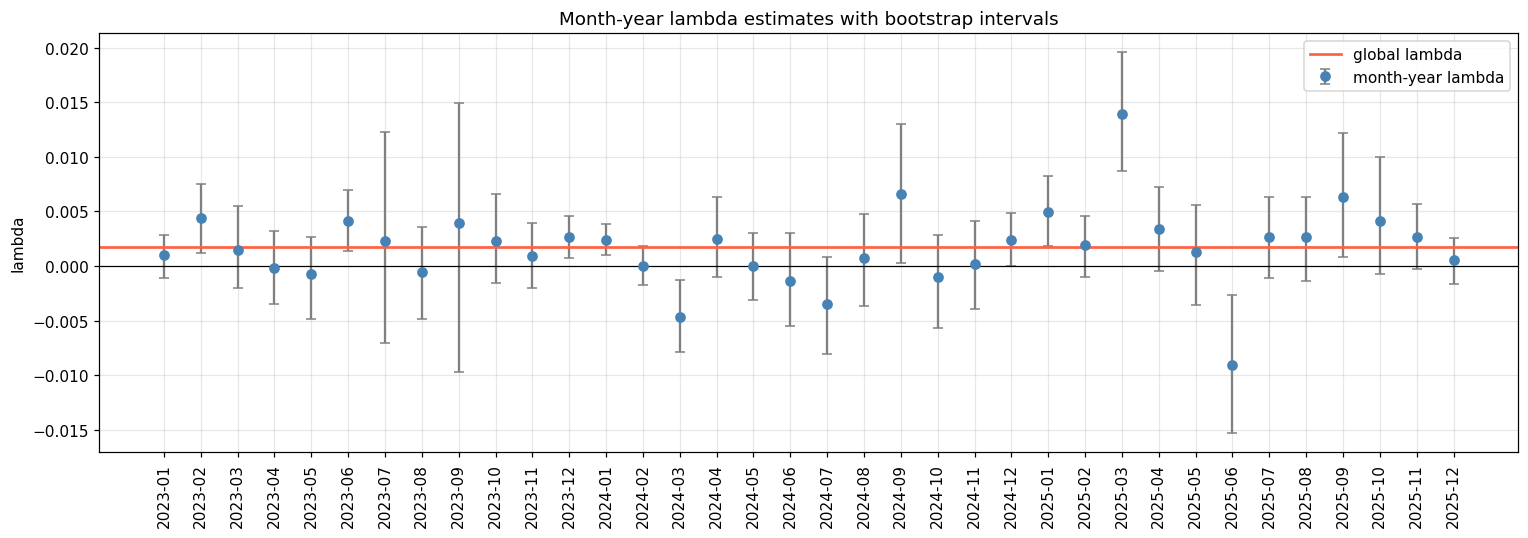

In [8]:
x = np.arange(len(period_lambda))
y = period_lambda["lambda_period"].to_numpy()
yerr = np.vstack([
    y - period_lambda["ci_lo"].to_numpy(),
    period_lambda["ci_hi"].to_numpy() - y,
])

fig, ax = plt.subplots(figsize=(14, 5))
ax.errorbar(x, y, yerr=yerr, fmt="o", capsize=3, color="steelblue", ecolor="gray", label="month-year lambda")
ax.axhline(lambda_global, color="tomato", lw=1.8, label="global lambda")
ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(period_lambda["period"], rotation=90)
ax.set_ylabel("lambda")
ax.set_title("Month-year lambda estimates with bootstrap intervals")
ax.legend()
plt.tight_layout()
plt.show()


## State residual scatter

This scatter uses the marginal CARMA projected state residuals $r_T=b_T'R_T$ and $r_X=b_X'R_X$. These residuals are the covariance objects used for the month-year estimates of $\lambda_t$.


,sample,n,pearson_r,spearman_r
0,marginal_projected_state_residuals,26280,-0.028846,-0.044737


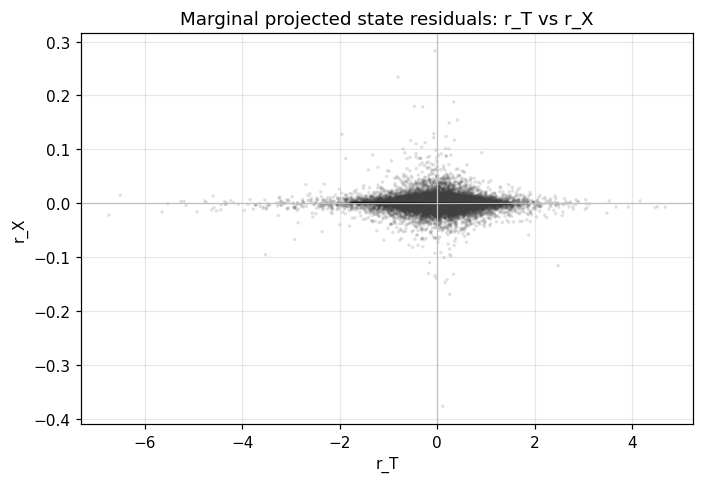

In [9]:
def safe_pearson_r(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if len(x) < 3 or np.std(x, ddof=1) == 0 or np.std(y, ddof=1) == 0:
        return np.nan
    return float(pearsonr(x, y).statistic)

def safe_spearman_r(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if len(x) < 3 or np.std(x, ddof=1) == 0 or np.std(y, ddof=1) == 0:
        return np.nan
    return float(spearmanr(x, y).statistic)

def centered_covariance_np(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    return float(np.mean((x - x.mean()) * (y - y.mean())))

def add_scatter_fit(ax, x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    finite = np.isfinite(x) & np.isfinite(y)
    x = x[finite]
    y = y[finite]
    if len(x) < 3 or np.std(x, ddof=1) == 0:
        return
    slope, intercept = np.polyfit(x, y, 1)
    xs = np.linspace(np.quantile(x, 0.01), np.quantile(x, 0.99), 100)
    ax.plot(xs, intercept + slope * xs, color="black", lw=1.1)

def neutral_scatter(ax, x, y, title, xlabel, ylabel):
    ax.scatter(x, y, s=5, alpha=0.16, color="0.25", edgecolors="none", rasterized=True)
    add_scatter_fit(ax, x, y)
    ax.axhline(0, color="0.75", lw=0.8)
    ax.axvline(0, color="0.75", lw=0.8)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)


scatter_global = pd.DataFrame({
    "sample": ["marginal_projected_state_residuals"],
    "n": [len(R_T_obs)],
    "pearson_r": [safe_pearson_r(R_T_obs, R_X_obs)],
    "spearman_r": [safe_spearman_r(R_T_obs, R_X_obs)],
})
display(scatter_global.round(8))

fig, ax = plt.subplots(figsize=(6.5, 4.5))
neutral_scatter(
    ax,
    R_T_obs,
    R_X_obs,
    "Marginal projected state residuals: r_T vs r_X",
    "r_T",
    "r_X",
)
plt.tight_layout()
plt.show()


## AIC and price fit


In [10]:
# Align observations for joint Kalman evaluation.
common_obs_idx = time_T.intersection(time_X).sort_values()
y_T_joint = temp_df.loc[common_obs_idx, "T"].to_numpy(float)
y_X_joint = price_df.loc[common_obs_idx, "X"].to_numpy(float)
y_joint = np.column_stack([y_T_joint, y_X_joint])
obs_periods = common_obs_idx.to_period("M").astype(str).to_numpy()

# Recovered scalar increments are used only to set a Gaussian idiosyncratic scale
# for the Kalman likelihood approximation.
dL_T_df = pd.read_csv("../data/levy/temp_levy_increments.csv", parse_dates=["datetime"])
dL_T_df["datetime"] = pd.to_datetime(dL_T_df["datetime"], utc=True)
dL_T_df = dL_T_df.rename(columns={"dL": "dL_T"})[["datetime", "dL_T"]]

dL_X_df = pd.read_csv("../data/levy/price_levy_increments.csv")
if "datetime" in dL_X_df.columns:
    dL_X_df["datetime"] = pd.to_datetime(dL_X_df["datetime"], utc=True)
else:
    dL_X_df = dL_X_df.copy()
    dL_X_df["datetime"] = time_X[1:len(dL_X_df) + 1].to_numpy()
dL_X_df = dL_X_df.rename(columns={"dL": "dL_X"})[["datetime", "dL_X"]]

levy_joint = dL_T_df.merge(dL_X_df, on="datetime", how="inner").sort_values("datetime")
levy_periods = levy_joint["datetime"].dt.to_period("M").astype(str).to_numpy()
period_lambda_map = dict(zip(period_lambda["period"], period_lambda["lambda_period"]))
lambda_for_levy_period = np.array([period_lambda_map.get(p, lambda_global) for p in levy_periods])

std_dL_X = float(levy_joint["dL_X"].std(ddof=1))
std_dL_T = float(levy_joint["dL_T"].std(ddof=1))
sigma_J_constant = float(np.sqrt(max(std_dL_X**2 - np.var(lambda_global * levy_joint["dL_T"], ddof=1), 1e-10)))
sigma_J_period = float(np.sqrt(max(std_dL_X**2 - np.var(lambda_for_levy_period * levy_joint["dL_T"].to_numpy(float), ddof=1), 1e-10)))

display(pd.DataFrame({"std_dL_X": [std_dL_X], "std_dL_T": [std_dL_T], "sigma_J_constant": [sigma_J_constant], "sigma_J_period": [sigma_J_period]}, index=["joint_kalman"]).round(8))


,std_dL_X,std_dL_T,sigma_J_constant,sigma_J_period
joint_kalman,0.759957,1.38228,0.759953,0.759936


In [11]:
def joint_matrices_for_lambda(lambda_value, sigma_j):
    p = p_T + p_X
    A_joint = np.zeros((p, p))
    A_joint[:p_T, :p_T] = A_T
    A_joint[p_T:, p_T:] = A_X

    H_joint = np.zeros((2, p))
    H_joint[0, :p_T] = b_T
    H_joint[1, p_T:] = b_X

    G_joint = np.zeros((p, 2))
    G_joint[:p_T, 0] = sigma_T * e_T
    G_joint[p_T:, 0] = lambda_value * sigma_T * e_X
    G_joint[p_T:, 1] = sigma_j * e_X
    return A_joint, H_joint, G_joint

def joint_kf_lambda_schedule(y_obs, times, lambda_schedule, sigma_j, R_obs):
    lambda_schedule = np.asarray(lambda_schedule, dtype=float)
    A0, H, G0 = joint_matrices_for_lambda(lambda_schedule[0], sigma_j)
    n, p = len(y_obs), A0.shape[0]
    nobs = H.shape[0]
    x = np.zeros(p)
    P = stationary_covariance(A0, G0) + np.eye(p) * 1e-6
    I = np.eye(p)
    y_pred = np.zeros((n, nobs))
    innov = np.zeros((n, nobs))
    S_arr = np.zeros((n, nobs, nobs))
    x_filt = np.zeros((n, p))
    loglik = 0.0
    cache = {}

    for k in range(n):
        if k > 0:
            dt = float((times[k] - times[k - 1]) / pd.Timedelta(hours=1))
            lam = float(lambda_schedule[k])
            key = (dt, round(lam, 14), round(sigma_j, 14))
            if key not in cache:
                A, H, G = joint_matrices_for_lambda(lam, sigma_j)
                cache[key] = van_loan(A, G, dt)
            F, Q = cache[key]
            x = F @ x
            P = F @ P @ F.T + Q

        mu = H @ x
        S = H @ P @ H.T + R_obs
        S = 0.5 * (S + S.T)
        v = y_obs[k] - mu
        Si = np.linalg.inv(S)
        K = P @ H.T @ Si
        x = x + K @ v
        P = (I - K @ H) @ P @ (I - K @ H).T + K @ R_obs @ K.T
        P = 0.5 * (P + P.T)

        y_pred[k] = mu
        innov[k] = v
        S_arr[k] = S
        x_filt[k] = x
        sign, logdet = np.linalg.slogdet(S)
        if sign <= 0:
            logdet = np.log(max(np.linalg.det(S), 1e-300))
        loglik += -0.5 * (nobs * np.log(2 * np.pi) + logdet + v @ Si @ v)

    return dict(y_pred=y_pred, innov=innov, S=S_arr, x_filt=x_filt, loglik=float(loglik))

obs_var = np.var(y_joint, axis=0, ddof=1)
R_obs_joint = np.diag(np.maximum(obs_var * 1e-6, 1e-10))

lambda_schedule_constant = np.full(len(common_obs_idx), lambda_global)
lambda_schedule_period = np.array([period_lambda_map.get(p, lambda_global) for p in obs_periods])

res_joint_constant = joint_kf_lambda_schedule(
    y_joint, common_obs_idx, lambda_schedule_constant, sigma_J_constant, R_obs_joint
)
res_joint_period = joint_kf_lambda_schedule(
    y_joint, common_obs_idx, lambda_schedule_period, sigma_J_period, R_obs_joint
)

joint_loglik_table = pd.DataFrame({
    "n_obs": [len(common_obs_idx)],
    "loglik_constant": [res_joint_constant["loglik"]],
    "loglik_period": [res_joint_period["loglik"]],
    "delta_loglik_period_minus_constant": [res_joint_period["loglik"] - res_joint_constant["loglik"]],
}, index=["joint_kalman"])
display(joint_loglik_table.round(8))


,n_obs,loglik_constant,loglik_period,delta_loglik_period_minus_constant
joint_kalman,26281,-23765.609089,-23765.121445,0.487643


In [12]:
def price_metrics(y_real, y_pred):
    idx = np.arange(1, len(y_real))
    err = y_real[idx] - y_pred[idx]
    rmse = float(np.sqrt(np.mean(err**2)))
    mae = float(np.mean(np.abs(err)))
    r2 = float(1 - np.sum(err**2) / np.sum((y_real[idx] - y_real[idx].mean())**2))
    return rmse, mae, r2

rmse_price_constant, mae_price_constant, r2_price_constant = price_metrics(
    y_X_joint, res_joint_constant["y_pred"][:, 1]
)
rmse_price_period, mae_price_period, r2_price_period = price_metrics(
    y_X_joint, res_joint_period["y_pred"][:, 1]
)

n_lambda_period = len(period_lambda)
n_marginal_params = 12  # temp CARMA 5 + price CARMA 7
k_fixed_constant = 2  # lambda_global + sigma_J
k_fixed_period = n_lambda_period + 1  # period lambdas + sigma_J
k_full_constant = n_marginal_params + k_fixed_constant
k_full_period = n_marginal_params + k_fixed_period

aic_constant_fixed = -2 * res_joint_constant["loglik"] + 2 * k_fixed_constant
aic_period_fixed = -2 * res_joint_period["loglik"] + 2 * k_fixed_period
aic_constant_full = -2 * res_joint_constant["loglik"] + 2 * k_full_constant
aic_period_full = -2 * res_joint_period["loglik"] + 2 * k_full_period

aic_comparison = pd.DataFrame({
    "loglik": [res_joint_constant["loglik"], res_joint_period["loglik"]],
    "n_lambda": [1, n_lambda_period],
    "sigma_J": [sigma_J_constant, sigma_J_period],
    "k_fixed_margins": [k_fixed_constant, k_fixed_period],
    "AIC_fixed_margins": [aic_constant_fixed, aic_period_fixed],
    "k_full_count": [k_full_constant, k_full_period],
    "AIC_full_count": [aic_constant_full, aic_period_full],
    "RMSE_price": [rmse_price_constant, rmse_price_period],
    "MAE_price": [mae_price_constant, mae_price_period],
    "R2_price": [r2_price_constant, r2_price_period],
}, index=["constant_lambda", "month_year_lambda"])

display(aic_comparison.round(8))
aic_delta_table = pd.DataFrame({"delta_AIC_fixed_period_minus_constant": [aic_period_fixed - aic_constant_fixed], "delta_AIC_full_period_minus_constant": [aic_period_full - aic_constant_full], "delta_RMSE_price_period_minus_constant": [rmse_price_period - rmse_price_constant]}, index=["month_year_minus_constant"])
display(aic_delta_table.round(8))


,loglik,n_lambda,sigma_J,k_fixed_margins,AIC_fixed_margins,k_full_count,AIC_full_count,RMSE_price,MAE_price,R2_price
constant_lambda,-23765.609089,1,0.759953,2,47535.218177,14,47559.218177,0.012308,0.007395,0.865690
month_year_lambda,-23765.121445,36,0.759936,37,47604.242890,49,47628.242890,0.012375,0.007478,0.864229


,delta_AIC_fixed_period_minus_constant,delta_AIC_full_period_minus_constant,delta_RMSE_price_period_minus_constant
month_year_minus_constant,69.024713,69.024713,0.000067


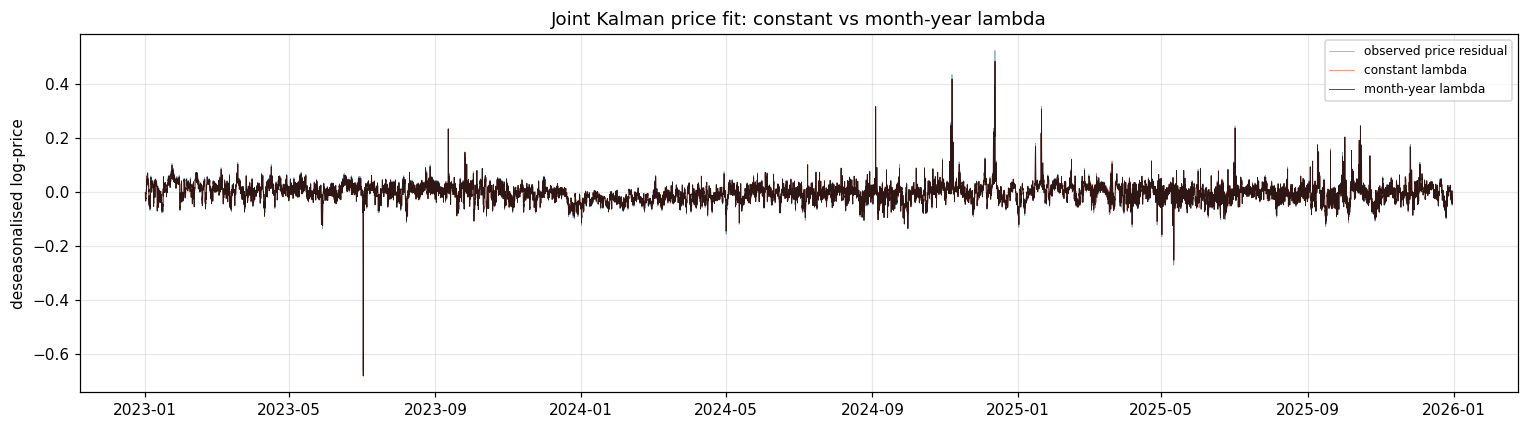

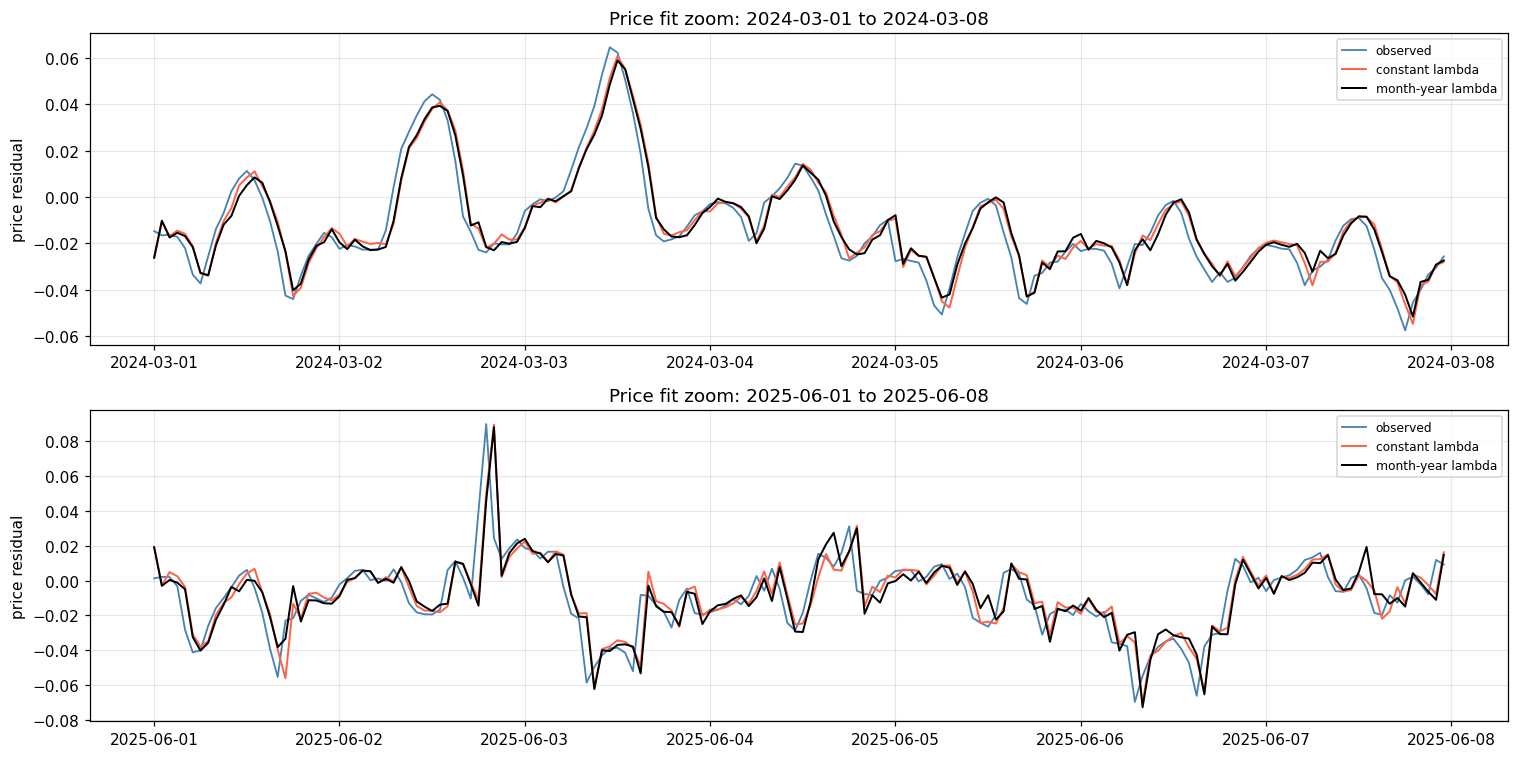

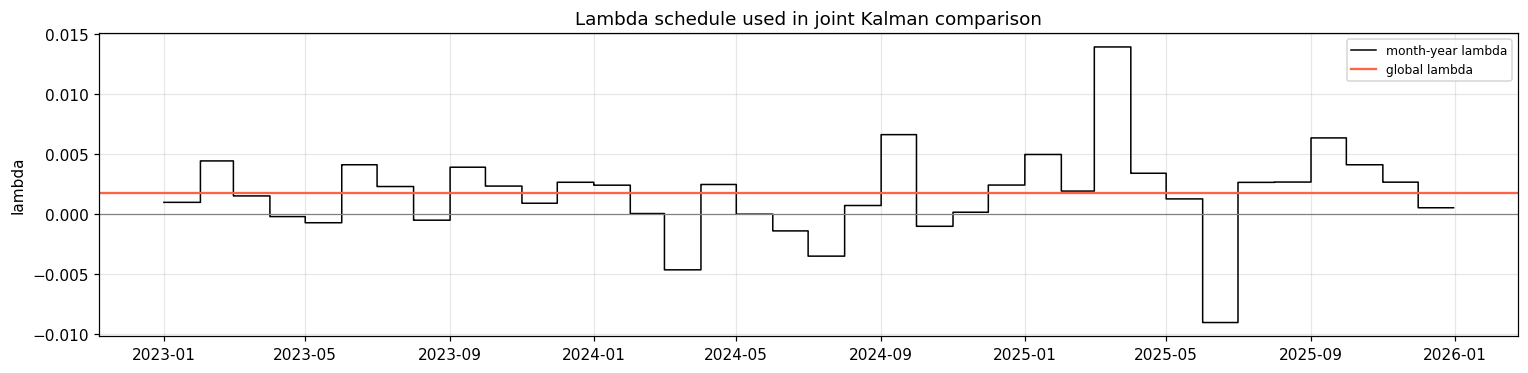

In [13]:
# Visual temporal fit: full period and two tight zooms around high-variation periods.
y_pred_price_constant = res_joint_constant["y_pred"][:, 1]
y_pred_price_period = res_joint_period["y_pred"][:, 1]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(common_obs_idx, y_X_joint, lw=0.45, alpha=0.75, color="steelblue", label="observed price residual")
ax.plot(common_obs_idx, y_pred_price_constant, lw=0.55, alpha=0.8, color="tomato", label="constant lambda")
ax.plot(common_obs_idx, y_pred_price_period, lw=0.55, alpha=0.8, color="black", label="month-year lambda")
ax.set_title("Joint Kalman price fit: constant vs month-year lambda")
ax.set_ylabel("deseasonalised log-price")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

zoom_windows = [
    ("2024-03-01", "2024-03-08"),
    ("2025-06-01", "2025-06-08"),
]

fig, axes = plt.subplots(len(zoom_windows), 1, figsize=(14, 7), sharex=False)
for ax, (start, end) in zip(axes, zoom_windows):
    mask = (common_obs_idx >= pd.Timestamp(start, tz="UTC")) & (
        common_obs_idx < pd.Timestamp(end, tz="UTC")
    )
    ax.plot(common_obs_idx[mask], y_X_joint[mask], lw=1.2, color="steelblue", label="observed")
    ax.plot(common_obs_idx[mask], y_pred_price_constant[mask], lw=1.3, color="tomato", label="constant lambda")
    ax.plot(common_obs_idx[mask], y_pred_price_period[mask], lw=1.3, color="black", label="month-year lambda")
    ax.set_title(f"Price fit zoom: {start} to {end}")
    ax.set_ylabel("price residual")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(14, 3.5))
ax.step(common_obs_idx, lambda_schedule_period, where="post", color="black", lw=1.0, label="month-year lambda")
ax.axhline(lambda_global, color="tomato", lw=1.5, label="global lambda")
ax.axhline(0, color="gray", lw=0.8)
ax.set_title("Lambda schedule used in joint Kalman comparison")
ax.set_ylabel("lambda")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## Joint innovations

The separate marginal CARMA filters give a benchmark based on two one-dimensional filters. They do not estimate a joint covariance, so the benchmark cross-covariance is zero.

For the coupled Kalman filters, the innovation is

$$v_k=y_k-\mathbb{E}[y_k\mid\mathcal{F}_{k-1}], \qquad S_k=\operatorname{Var}(v_k\mid\mathcal{F}_{k-1}).$$

Raw temperature-price innovations may be correlated when $S_{TX,k}$ is non-zero. The joint covariance check compares

$$\frac{1}{n}\sum_k v_{T,k}v_{X,k} \quad \text{with} \quad \frac{1}{n}\sum_k S_{TX,k}.$$


,n,mean_v_T,mean_v_X,empirical_E_vT_vX,empirical_centered_cov_v,mean_model_S_TX,raw_cov_error,empirical_corr_v,mean_model_corr
model,,,,,,,,,
separate_marginals,26280,0.002815,0.000001,-0.000208,-0.000208,0.000000,-0.000208,-0.028846,0.000000
constant_lambda,26280,0.002822,-0.000004,-0.000211,-0.000211,-0.000222,0.000011,-0.029244,-0.000896
month_year_lambda,26280,0.002822,-0.000001,-0.000253,-0.000253,-0.000216,-0.000037,-0.034920,-0.000872


,model,sample,pearson_r,spearman_r
0,separate_marginals,one_step_predictions,-0.050979,-0.047908
1,separate_marginals,raw_innovations,-0.028846,-0.044737
2,constant_lambda,one_step_predictions,-0.043789,-0.040152
3,constant_lambda,raw_innovations,-0.029244,-0.050320
4,month_year_lambda,one_step_predictions,-0.044265,-0.040855
5,month_year_lambda,raw_innovations,-0.034920,-0.055268


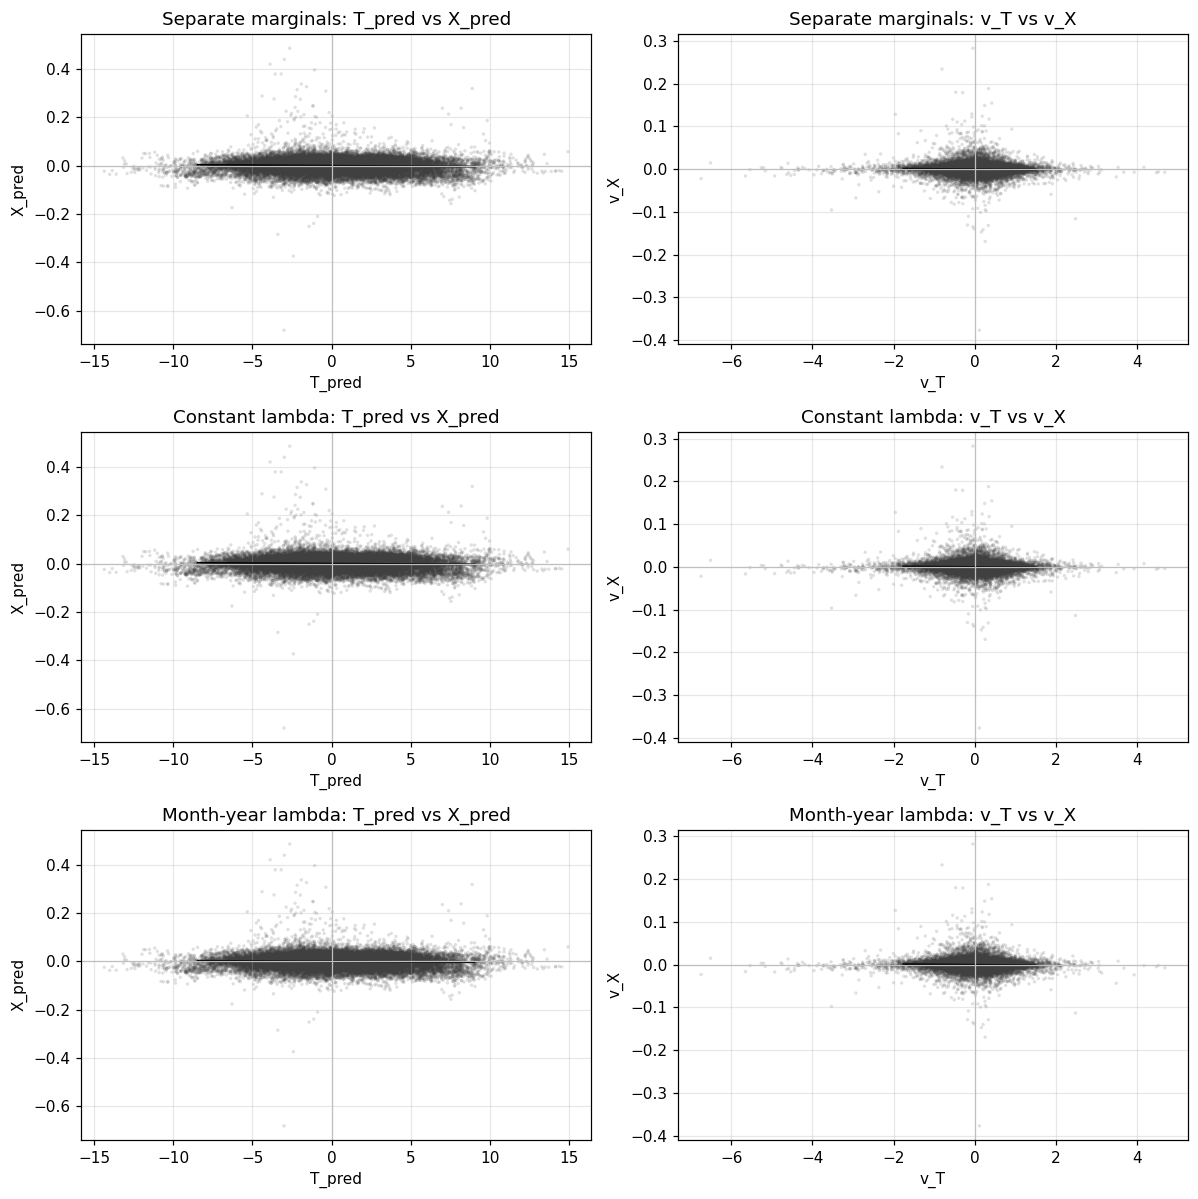

In [14]:
def safe_pearson_r(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if len(x) < 3 or np.std(x, ddof=1) == 0 or np.std(y, ddof=1) == 0:
        return np.nan
    return float(pearsonr(x, y).statistic)

def safe_spearman_r(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if len(x) < 3 or np.std(x, ddof=1) == 0 or np.std(y, ddof=1) == 0:
        return np.nan
    return float(spearmanr(x, y).statistic)

def centered_covariance_np(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    return float(np.mean((x - x.mean()) * (y - y.mean())))

def add_scatter_fit(ax, x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    finite = np.isfinite(x) & np.isfinite(y)
    x = x[finite]
    y = y[finite]
    if len(x) < 3 or np.std(x, ddof=1) == 0:
        return
    slope, intercept = np.polyfit(x, y, 1)
    xs = np.linspace(np.quantile(x, 0.01), np.quantile(x, 0.99), 100)
    ax.plot(xs, intercept + slope * xs, color="black", lw=1.1)

def neutral_scatter(ax, x, y, title, xlabel, ylabel):
    ax.scatter(x, y, s=5, alpha=0.16, color="0.25", edgecolors="none", rasterized=True)
    add_scatter_fit(ax, x, y)
    ax.axhline(0, color="0.75", lw=0.8)
    ax.axvline(0, color="0.75", lw=0.8)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)


def joint_raw_innovation_summary(name, innov, S_arr, start=1):
    """Compare raw joint innovations v_k with their model covariance S_k."""
    v = np.asarray(innov[start:], dtype=float)
    S = np.asarray(S_arr[start:], dtype=float)
    rho_model = S[:, 0, 1] / np.sqrt(S[:, 0, 0] * S[:, 1, 1])
    row = {
        "model": name,
        "n": len(v),
        "mean_v_T": float(v[:, 0].mean()),
        "mean_v_X": float(v[:, 1].mean()),
        "empirical_E_vT_vX": float(np.mean(v[:, 0] * v[:, 1])),
        "empirical_centered_cov_v": centered_covariance_np(v[:, 0], v[:, 1]),
        "mean_model_S_TX": float(S[:, 0, 1].mean()),
        "raw_cov_error": float(np.mean(v[:, 0] * v[:, 1]) - S[:, 0, 1].mean()),
        "empirical_corr_v": safe_pearson_r(v[:, 0], v[:, 1]),
        "mean_model_corr": float(rho_model.mean()),
    }
    return row, v, S

def marginal_raw_innovation_summary(name, v_T, v_X):
    """Separate marginal filters do not define S_TX; zero is the independence benchmark."""
    v = np.column_stack([np.asarray(v_T, dtype=float), np.asarray(v_X, dtype=float)])
    row = {
        "model": name,
        "n": len(v),
        "mean_v_T": float(v[:, 0].mean()),
        "mean_v_X": float(v[:, 1].mean()),
        "empirical_E_vT_vX": float(np.mean(v[:, 0] * v[:, 1])),
        "empirical_centered_cov_v": centered_covariance_np(v[:, 0], v[:, 1]),
        "mean_model_S_TX": 0.0,
        "raw_cov_error": float(np.mean(v[:, 0] * v[:, 1])),
        "empirical_corr_v": safe_pearson_r(v[:, 0], v[:, 1]),
        "mean_model_corr": 0.0,
    }
    return row, v


marginal_pred_T_series = pd.Series(y_T - res_kf_T["innov"], index=time_T)
marginal_pred_X_series = pd.Series(y_X - res_kf_X["innov"], index=time_X)
marginal_v_T_series = pd.Series(res_kf_T["innov"], index=time_T)
marginal_v_X_series = pd.Series(res_kf_X["innov"], index=time_X)

marginal_pred_T = marginal_pred_T_series.loc[common_obs_idx].to_numpy(float)[1:]
marginal_pred_X = marginal_pred_X_series.loc[common_obs_idx].to_numpy(float)[1:]
marginal_v_T = marginal_v_T_series.loc[common_obs_idx].to_numpy(float)[1:]
marginal_v_X = marginal_v_X_series.loc[common_obs_idx].to_numpy(float)[1:]

row_marginal, v_marginal = marginal_raw_innovation_summary(
    "separate_marginals", marginal_v_T, marginal_v_X
)
row_constant, v_constant, S_constant_eval = joint_raw_innovation_summary(
    "constant_lambda", res_joint_constant["innov"], res_joint_constant["S"], start=1
)
row_period, v_period, S_period_eval = joint_raw_innovation_summary(
    "month_year_lambda", res_joint_period["innov"], res_joint_period["S"], start=1
)

innovation_covariance_comparison = pd.DataFrame([
    row_marginal, row_constant, row_period
]).set_index("model")
display(innovation_covariance_comparison.round(8))

scatter_comparison = pd.DataFrame([
    {
        "model": "separate_marginals",
        "sample": "one_step_predictions",
        "pearson_r": safe_pearson_r(marginal_pred_T, marginal_pred_X),
        "spearman_r": safe_spearman_r(marginal_pred_T, marginal_pred_X),
    },
    {
        "model": "separate_marginals",
        "sample": "raw_innovations",
        "pearson_r": safe_pearson_r(marginal_v_T, marginal_v_X),
        "spearman_r": safe_spearman_r(marginal_v_T, marginal_v_X),
    },
    {
        "model": "constant_lambda",
        "sample": "one_step_predictions",
        "pearson_r": safe_pearson_r(res_joint_constant["y_pred"][1:, 0], res_joint_constant["y_pred"][1:, 1]),
        "spearman_r": safe_spearman_r(res_joint_constant["y_pred"][1:, 0], res_joint_constant["y_pred"][1:, 1]),
    },
    {
        "model": "constant_lambda",
        "sample": "raw_innovations",
        "pearson_r": safe_pearson_r(v_constant[:, 0], v_constant[:, 1]),
        "spearman_r": safe_spearman_r(v_constant[:, 0], v_constant[:, 1]),
    },
    {
        "model": "month_year_lambda",
        "sample": "one_step_predictions",
        "pearson_r": safe_pearson_r(res_joint_period["y_pred"][1:, 0], res_joint_period["y_pred"][1:, 1]),
        "spearman_r": safe_spearman_r(res_joint_period["y_pred"][1:, 0], res_joint_period["y_pred"][1:, 1]),
    },
    {
        "model": "month_year_lambda",
        "sample": "raw_innovations",
        "pearson_r": safe_pearson_r(v_period[:, 0], v_period[:, 1]),
        "spearman_r": safe_spearman_r(v_period[:, 0], v_period[:, 1]),
    },
])
display(scatter_comparison.round(8))

fig, axes = plt.subplots(3, 2, figsize=(11, 11))
neutral_scatter(
    axes[0, 0],
    marginal_pred_T,
    marginal_pred_X,
    "Separate marginals: T_pred vs X_pred",
    "T_pred",
    "X_pred",
)
neutral_scatter(
    axes[0, 1],
    marginal_v_T,
    marginal_v_X,
    "Separate marginals: v_T vs v_X",
    "v_T",
    "v_X",
)
neutral_scatter(
    axes[1, 0],
    res_joint_constant["y_pred"][1:, 0],
    res_joint_constant["y_pred"][1:, 1],
    "Constant lambda: T_pred vs X_pred",
    "T_pred",
    "X_pred",
)
neutral_scatter(
    axes[1, 1],
    v_constant[:, 0],
    v_constant[:, 1],
    "Constant lambda: v_T vs v_X",
    "v_T",
    "v_X",
)
neutral_scatter(
    axes[2, 0],
    res_joint_period["y_pred"][1:, 0],
    res_joint_period["y_pred"][1:, 1],
    "Month-year lambda: T_pred vs X_pred",
    "T_pred",
    "X_pred",
)
neutral_scatter(
    axes[2, 1],
    v_period[:, 0],
    v_period[:, 1],
    "Month-year lambda: v_T vs v_X",
    "v_T",
    "v_X",
)
plt.tight_layout()
plt.show()


## Saved tables


In [15]:
out_path = "../data/levy/monthly_coupling_estimate.csv"
period_lambda.to_csv(out_path, index=False)
rolling_prediction.to_csv("../data/levy/monthly_lambda_rolling_prediction.csv", index=False)
aic_comparison.to_csv("../data/levy/monthly_lambda_aic_comparison.csv")
innovation_covariance_comparison.to_csv("../data/levy/monthly_lambda_innovation_covariance_comparison.csv")
saved_tables = pd.DataFrame({
    "path": [
        out_path,
        "../data/levy/monthly_lambda_rolling_prediction.csv",
        "../data/levy/monthly_lambda_aic_comparison.csv",
        "../data/levy/monthly_lambda_innovation_covariance_comparison.csv",
    ]
})
display(saved_tables)


,path
0,../data/levy/monthly_coupling_estimate.csv
1,../data/levy/monthly_lambda_rolling_prediction...
2,../data/levy/monthly_lambda_aic_comparison.csv
3,../data/levy/monthly_lambda_innovation_covaria...


## Summary


In [16]:
summary_metrics = pd.DataFrame({
    "value": {
        "lambda_global": lambda_global,
        "lambda_global_se": lambda_global_se,
        "lambda_global_ci_95_lo": lambda_global_ci[0],
        "lambda_global_ci_95_hi": lambda_global_ci[1],
        "lambda_period_min": period_lambda["lambda_period"].min(),
        "lambda_period_max": period_lambda["lambda_period"].max(),
        "has_sign_changes": has_sign_changes,
        "n_period_CI_including_zero": n_zero_ci,
        "in_sample_rmse_constant": rmse_cov_constant,
        "in_sample_rmse_period": rmse_cov_period,
        "rolling_rmse_constant_expanding": rmse_constant_expanding,
        "rolling_rmse_lambda_expanding": rmse_lambda_expanding,
        "rolling_rmse_same_month_history": rmse_same_month_history,
        "joint_loglik_constant": res_joint_constant["loglik"],
        "joint_loglik_period": res_joint_period["loglik"],
        "AIC_fixed_constant": aic_constant_fixed,
        "AIC_fixed_period": aic_period_fixed,
        "delta_AIC_fixed_period_minus_constant": aic_period_fixed - aic_constant_fixed,
        "AIC_full_constant": aic_constant_full,
        "AIC_full_period": aic_period_full,
        "delta_AIC_full_period_minus_constant": aic_period_full - aic_constant_full,
        "RMSE_price_constant": rmse_price_constant,
        "RMSE_price_period": rmse_price_period,
        "raw_cov_error_marginal": innovation_covariance_comparison.loc["separate_marginals", "raw_cov_error"],
        "raw_cov_error_constant": innovation_covariance_comparison.loc["constant_lambda", "raw_cov_error"],
        "raw_cov_error_period": innovation_covariance_comparison.loc["month_year_lambda", "raw_cov_error"],
    }
})
display(summary_metrics.round(8))


,value
lambda_global,0.001749
lambda_global_se,0.000386
lambda_global_ci_95_lo,0.000948
lambda_global_ci_95_hi,0.002427
lambda_period_min,-0.009029
lambda_period_max,0.013919
has_sign_changes,True
n_period_CI_including_zero,25
in_sample_rmse_constant,0.000427
in_sample_rmse_period,0.0
